In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph  , START , END
from dotenv import load_dotenv
from typing import TypedDict
load_dotenv()

True

In [12]:
model = ChatGoogleGenerativeAI(model = 'gemini-2.5-flash')

In [13]:
class LLMstate(TypedDict):
    topic: str
    summary:str
    quiz:str

In [14]:
graph = StateGraph(LLMstate)

In [15]:
def summary_gen(state: LLMstate)-> LLMstate:
    topic = state['topic']
    prompt = f"You are a professional Assistant the students will tell topics thatw ill be {topic} summarize them"
    summary = model.invoke(prompt)
    state["summary"] = summary
    
    return state

In [16]:
def quiz_gen(state: LLMstate)-> LLMstate:
    summary = state['summary']
    prompt = f"This is Summary that is {summary}. Generate Quiz from this Summary Only"
    quiz = model.invoke(prompt)
    state['quiz']= quiz

    return state


In [17]:
graph.add_node("summary_gen" , summary_gen)
graph.add_node("quiz_gen" , quiz_gen)

In [18]:
graph.add_edge(START , "summary_gen")
graph.add_edge('summary_gen' , 'quiz_gen')
graph.add_edge('quiz_gen' , END)
workflow = graph.compile()

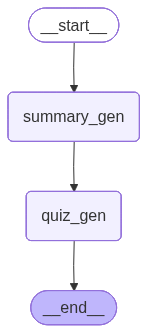

In [19]:
workflow

In [21]:
start_state = {'topic' : 'LangChain'}

end_state = workflow.invoke(start_state)

print(end_state["quiz"])

content='Here\'s a quiz generated from the provided summary:\n\n---\n\n**Quiz: Understanding Your LangChain Summarization Assistant**\n\n**Instructions:** Answer the following questions based *only* on the summary provided.\n\n1.  **Multiple Choice:** What is the primary goal of this LangChain summarization assistant?\n    a) To write LangChain code snippets.\n    b) To provide clear, concise, and easy-to-understand summaries of LangChain topics.\n    c) To debug LangChain applications.\n    d) To teach advanced Python programming.\n\n2.  **True or False:** The assistant is designed only for users who are just starting out with LangChain.\n    a) True\n    b) False\n\n3.  **Fill-in-the-Blank:** To get a summary, the user simply needs to tell the assistant the \\_\\_\\_\\_\\_\\_\\_\\_\\_\\_\\_\\_\\_\\_\\_ they\'d like summarized.\n\n4.  **Multiple Choice (Select All That Apply):** When the assistant provides a summary, what types of information will it include?\n    a) A brief overview\

In [23]:
print(end_state["summary"].content)
print(end_state["quiz"].content)

Hello there! I'm ready to be your dedicated LangChain summarization assistant.

My goal is to provide clear, concise, and easy-to-understand summaries of any LangChain topic you throw my way. Whether you're just starting out or diving into more advanced concepts, I'll break it down for you.

**How it works:**

Simply tell me the LangChain topic you'd like summarized. For example, you can say:

*   "Summarize 'Chains' for me."
*   "What is 'Agents' in LangChain?"
*   "Tell me about 'Memory' in LangChain."
*   "Explain 'Retrieval-Augmented Generation (RAG)'."
*   "What are 'Document Loaders'?"

I'll provide a brief overview, key components, and why it's important.

Let's get started! What's the first LangChain topic you'd like to explore?
Here's a quiz generated from the provided summary:

---

**Quiz: Understanding Your LangChain Summarization Assistant**

**Instructions:** Answer the following questions based *only* on the summary provided.

1.  **Multiple Choice:** What is the primary